# U.S. School District Finance, FY2012 — Revenue, Spending, and Funding Equity

Built from the Census Bureau's F-33 Annual Survey of School System Finances
(18,373 raw district records), cleaned with `src/clean.py`: missing-code
handling, filtering to unified school districts, and per-pupil calculations
done correctly at the state level (totals first, then divide).


## 1. Load the cleaned data

In [1]:
import pandas as pd

ss = pd.read_csv('data/processed/state_summary.csv')
d = pd.read_csv('data/processed/districts_clean.csv')
dc = pd.read_csv('data/processed/districts_comparable.csv')
print(f"State summary: {ss.shape}")
print(f"All clean districts: {d.shape}")
print(f"Comparable districts (100+ enrollment): {dc.shape}")

State summary: (51, 22)
All clean districts: (11173, 26)
Comparable districts (100+ enrollment): (10929, 26)


## 2. Revenue per pupil, by state — top and bottom

In [2]:
top5 = ss.nlargest(5,'revenue_per_pupil')[['state_name','revenue_per_pupil']]
bot5 = ss.nsmallest(5,'revenue_per_pupil')[['state_name','revenue_per_pupil']]
print("Top 5:"); print(top5.to_string(index=False))
print("\nBottom 5:"); print(bot5.to_string(index=False))

Top 5:
          state_name  revenue_per_pupil
District of Columbia           28196.87
            New York           22250.79
          New Jersey           20650.99
         Connecticut           18848.50
             Wyoming           18616.09

Bottom 5:
    state_name  revenue_per_pupil
         Idaho            7320.81
          Utah            7453.37
       Arizona            8106.00
      Oklahoma            8756.33
North Carolina            8770.33


## 3. The full state ranking

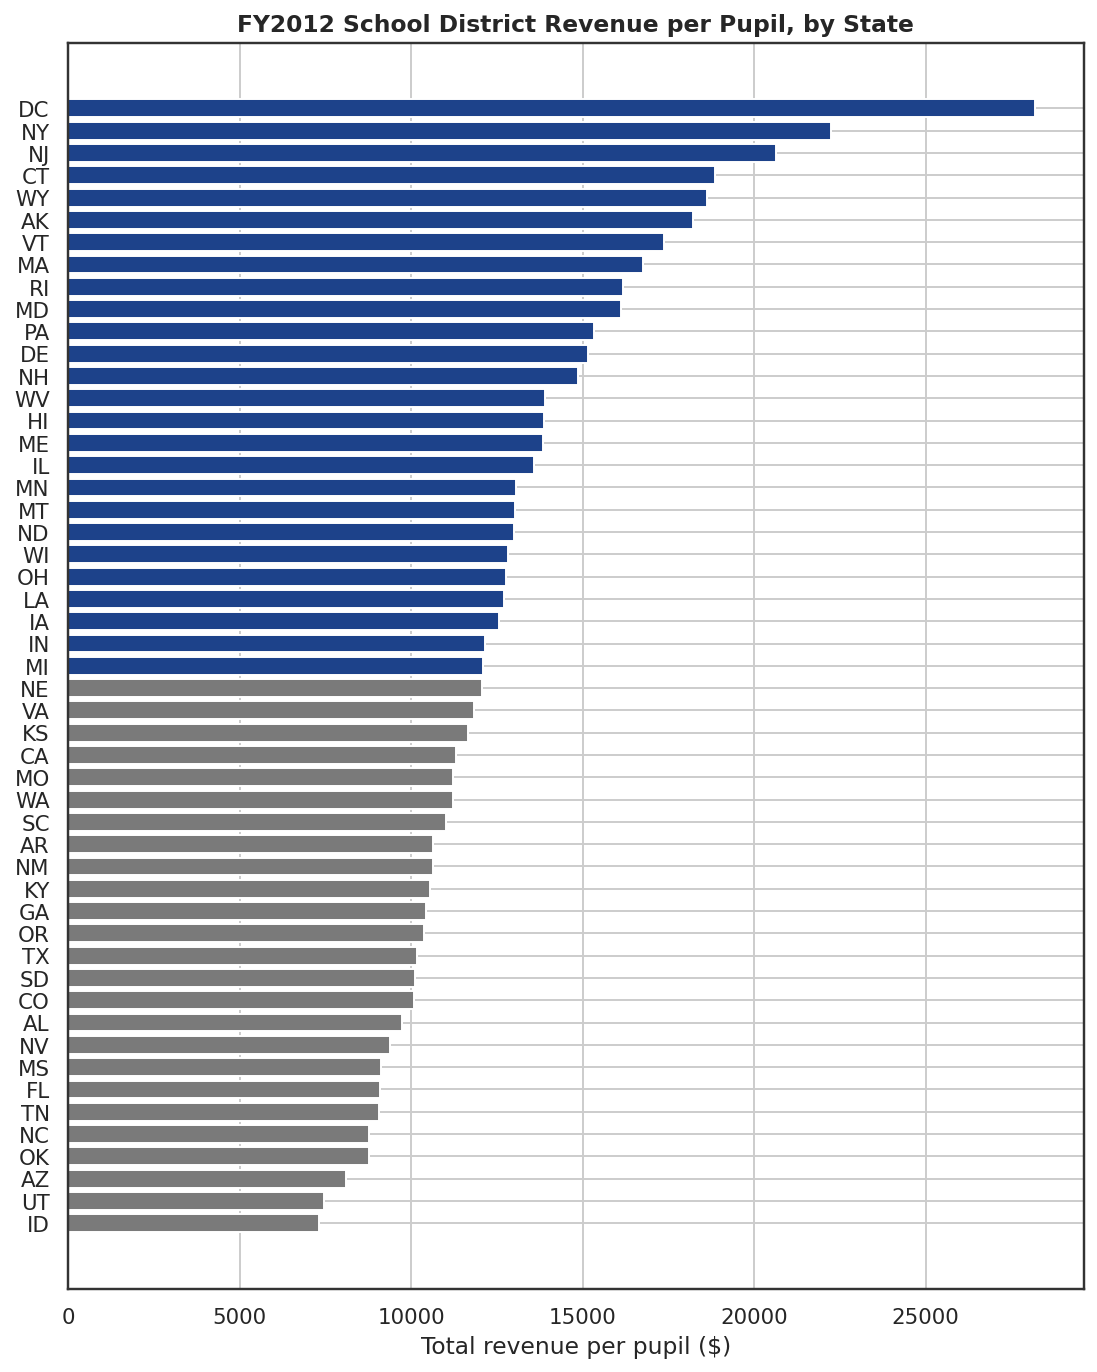

In [3]:
fig, ax = plt.subplots(figsize=(8,10))
d5 = ss.sort_values('revenue_per_pupil')
colors = ['#1D428A' if v >= d5['revenue_per_pupil'].median() else '#7A7A7A' for v in d5['revenue_per_pupil']]
ax.barh(d5['state_abbr'], d5['revenue_per_pupil'], color=colors)
ax.set_xlabel('Total revenue per pupil ($)')
ax.set_title('FY2012 School District Revenue per Pupil, by State')
plt.show()

## 4. Headline finding: funding source predicts spending level

Correlating each state's revenue mix against its overall per-pupil spending
shows a clear pattern: local funding share correlates positively with total
spending, federal funding share correlates negatively.

In [4]:
corr = ss[['revenue_per_pupil','federal_share_pct','state_share_pct','local_share_pct']].corr()['revenue_per_pupil']
print("Correlation with revenue_per_pupil:\n")
print(corr.round(3))

Correlation with revenue_per_pupil:

revenue_per_pupil    1.000
federal_share_pct   -0.453
state_share_pct     -0.276
local_share_pct      0.362


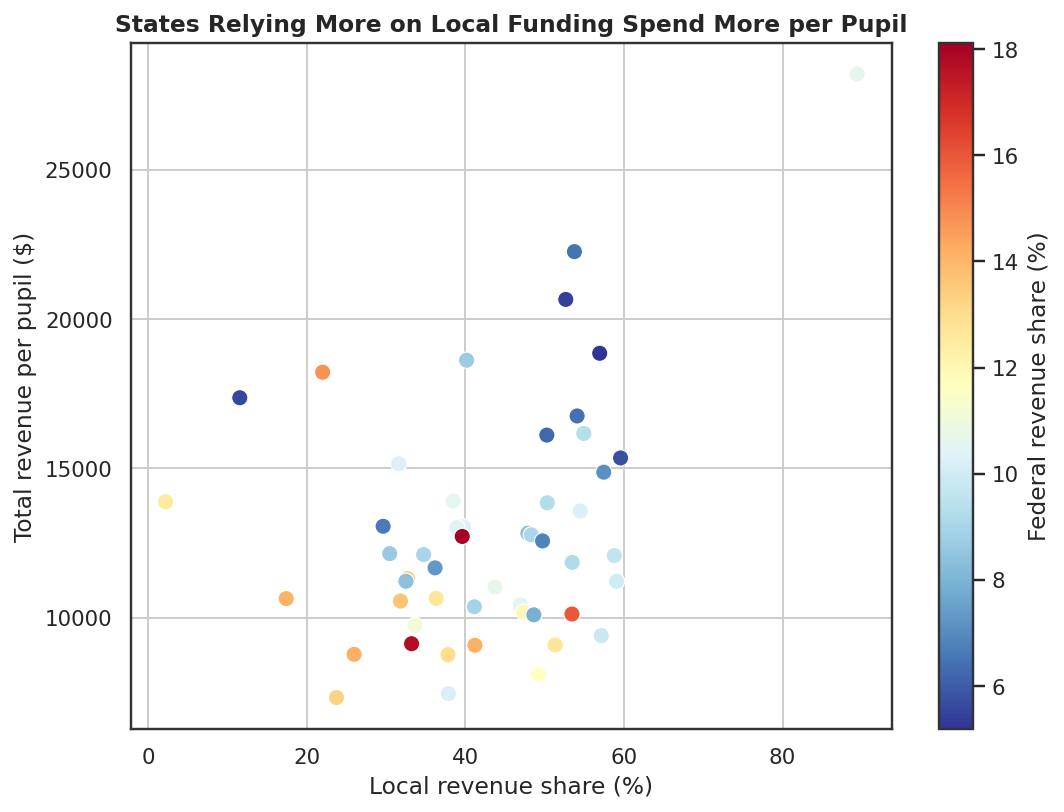

In [5]:
fig, ax = plt.subplots(figsize=(8,6))
sc = ax.scatter(ss['local_share_pct'], ss['revenue_per_pupil'], c=ss['federal_share_pct'],
                 cmap='RdYlBu_r', s=70, edgecolor='white', linewidth=0.6)
fig.colorbar(sc, ax=ax).set_label('Federal revenue share (%)')
ax.set_xlabel('Local revenue share (%)'); ax.set_ylabel('Total revenue per pupil ($)')
ax.set_title('States Relying More on Local Funding Spend More per Pupil')
plt.show()

## 5. District-level distribution

Using `districts_comparable.csv` (100+ enrollment only) — a handful of tiny
special-education cooperatives were excluded here since their per-pupil
figures (over $1,000,000 in the most extreme case) reflect small, specialized
service budgets divided over very few students, not comparable spending.

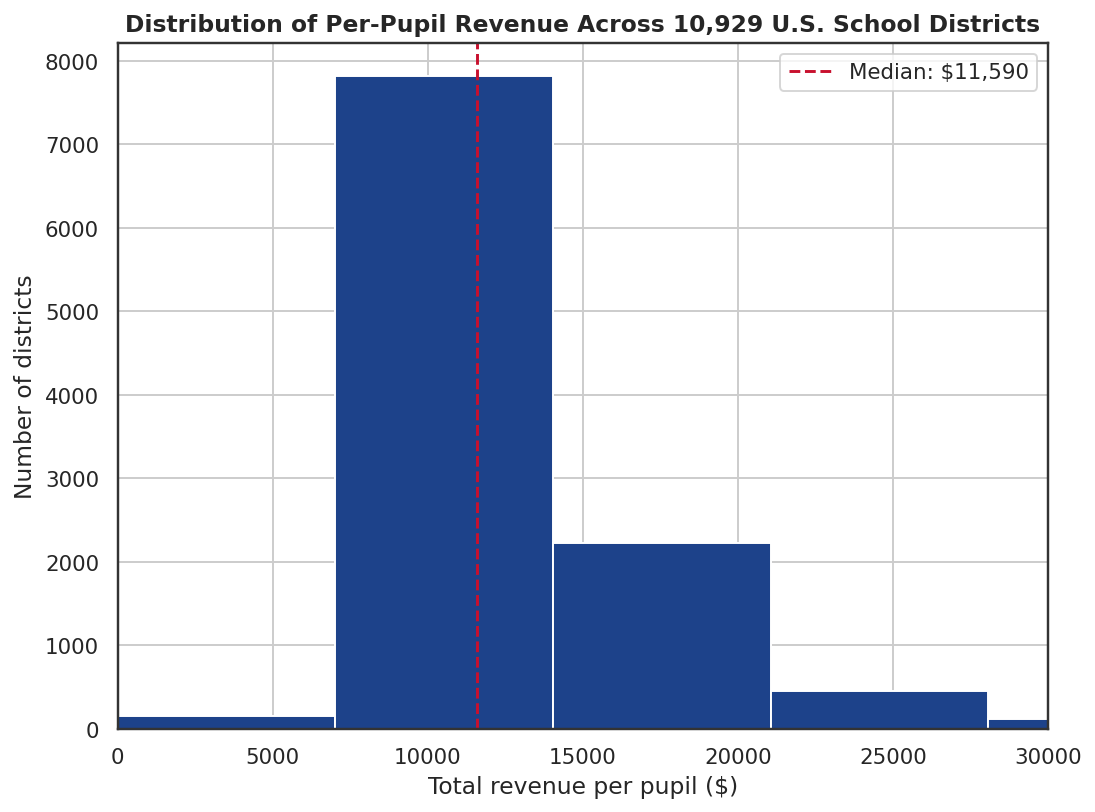

In [6]:
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(dc['total_rev_per_pupil'], bins=60, color='#1D428A', edgecolor='white')
ax.axvline(dc['total_rev_per_pupil'].median(), color='#C8102E', linestyle='--',
           label=f"Median: ${dc['total_rev_per_pupil'].median():,.0f}")
ax.set_xlim(0, 30000)
ax.set_xlabel('Total revenue per pupil ($)'); ax.set_ylabel('Number of districts')
ax.legend()
plt.show()

## 6. Conclusions

- Per-pupil revenue varies almost 4x across states ($7,321 to $28,197),
  driven substantially by how each state's school funding system is
  structured, not just by wealth alone.
- Higher local funding share associates with higher overall spending;
  higher federal funding share associates with lower overall spending —
  consistent with federal aid being largely compensatory, targeted at
  lower-resource systems rather than a source of overall abundance.
- A small number of extreme outlier districts (special-education
  cooperatives with very few students) were deliberately identified and
  excluded from district-level comparisons, while remaining fully present
  in the unrestricted processed file — nothing was silently discarded.
